In [7]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [8]:
df = pd.read_csv("IMDB Dataset.csv")

In [9]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'This is a typical late Universal Horror flick: its technically comptent, if by the numbers, with a cookie cutter plot and some serious overacting. The most interesting part of this film is its stunt casting of Rondo Hatton, a man with a bone disease as the film\'s "monster". Its sad to see this man exploited, but he probably made good use of the money they paid him. Hatton is less horrifying than the studio hoped, as I more often felt pity over fear or even loathing. Martin Koslack is on board as the film\'s mad artist, and he is very amusing in this part. I for one enjoy seeing Koslack in just about anything; for some reason the man amuses me. The only other part of the film that entertained me is the film\'s absurd take on the art world. Here we are shown evil art critics who revel in their ability to break artists; this is side by side with the film\'s male "hero" who is an "artist" who paints...get this...pin up girls. Somehow our hero\'s work is reviewed side by side with the vil

In [11]:
print(preprocess(df.iloc[random_num]['review']))

typical late universal horror flick technically comptent number cookie cutter plot serious overacting interesting part film stunt casting rondo hatton man bone disease film monster sad see man exploited probably made good use money paid hatton less horrifying studio hoped often felt pity fear even loathing martin koslack board film mad artist amusing part one enjoy seeing koslack anything reason man amuses part film entertained film absurd take art world shown evil art critic revel ability break artist side side film male hero artist paint get pin girl somehow hero work reviewed side side villan absurdist sculpture also amusing film chief nasty critic one point claim despises hero pin art woman like exist heroine reply assurance critic get enough finally bit subplot heroine art critic domestication leading man completely anti feminist ridiculous witness overall film rather mediocre picture amusing element


In [12]:
df['review'] = df['review'].apply(preprocess)

In [13]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [14]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [16]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [17]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [18]:
max_len = 20

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [19]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 4)          │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 20, 4)          │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,633 (318.88 KB)

 Trainable params: 81,633 (318.88 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [21]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5514 - loss: 0.6837 - val_accuracy: 0.6929 - val_loss: 0.5944 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7294 - loss: 0.5514 - val_accuracy: 0.7797 - val_loss: 0.4716 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7828 - loss: 0.4738 - val_accuracy: 0.7919 - val_loss: 0.4412 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8083 - loss: 0.4316 - val_accuracy: 0.7980 - val_loss: 0.4347 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8232 - loss: 0.4070 - val_accuracy: 0.7964 - val_loss: 0.4405 - learning_rate: 5.0000e-04


In [22]:
lstm_model.save_weights("lstm_modelo_leve.weights.h5")

In [23]:

lstm_model.load_weights("lstm_modelo_leve.weights.h5")

In [24]:
#Comentado por não ser acessário treinar rede novamente

""" plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()"""

' plt.figure(figsize=(10,5))\n\nplt.plot(lstm_history.history[\'accuracy\'], label=\'Train Acc\')\nplt.plot(lstm_history.history[\'val_accuracy\'], label=\'Val Acc\')\n\nplt.title("Model Accuracy")\nplt.xlabel("Epoch")\nplt.ylabel("Accuracy")\nplt.legend()\nplt.show()'

In [25]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8012 - loss: 0.4274
Test Accuracy: 0.8011999726295471


# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


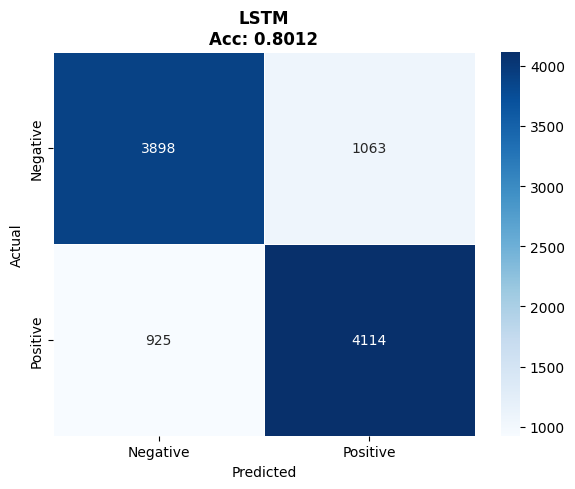

In [26]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [27]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.81      0.79      0.80      4961
    Positive       0.79      0.82      0.81      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



# Teste de Outputs


In [28]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = X_test_pad[0].tolist()

outputs = inspection_model.predict(np.array([x]))

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
Outputs salvos em layer_outputs_simplified_model.txt


# Exportação de Pesos

In [ ]:
export_weights(lstm_model, mode='lstm', output_file="../../Geral Tests SystemVerilog/Simplest Neural Network/weights.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_input[0][0] = 0.151423
  addr=0x08001 Wx_input[0][1] = -0.113860
  addr=0x08080 Wx_input[1][0] = 0.010775
  addr=0x08081 Wx_input[1][1] = 0.318696
  addr=0x08040 Wh_input[0][0] = -0.226885
  addr=0x08041 Wh_input[0][1] = -0.121314
  addr=0x080C0 Wh_input[1][0] = -0.135579
  addr=0x080C1 Wh_input[1][1] = 0.106893
  addr=0x18000 bias_input[0] = 0.119321
  addr=0x18080 bias_input[1] = 0.159041
  addr=0x0A000 Wx_forget[0][0] = 0.117003
  addr=0x0A001 Wx_forget[0][1] = -0.187944
  addr=0x0A080 Wx_forget[1][0] = 0.314509
  addr=0x0A081 Wx_forget[1][1] = -0.269843
  addr=0x0A040 Wh_forget[0][0] = -0.002738
  addr=0x0A041 Wh_forget[0][1] = -0.066391
  addr=0x0A0C0 Wh_forget[1][0] = -0.165137
  addr=0x0A0C1 Wh_forget[1][1] = -0.182316
  addr=0x1A000 bias_forget[0] = 1.063400
  addr=0x1A080 bias_forget[1] = 1.052192
  addr=0x0C000 Wx_candidate[0][0] = -0.551486
  addr=

# Teste Global

In [30]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [31]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(ground_result) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [ ]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)
#total = len(y_pred_lstm)
total = 10

for i in range(total):
    x = np.array([X_test_pad[i].tolist()])

    outputs = inspection_model.predict(x)
    
    export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[i], f"../../Geral Tests SystemVerilog/Simplest Neural Network/Small Global Processing/dados_{i}.mem")

    print(f"{i} de {total}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 601ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_0.mem
0 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_1.mem
1 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_2.mem
2 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_3.mem
3 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_4.mem
4 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural Network/Small Global Processing/dados_5.mem
5 de 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Arquivo salvo: ../../Geral Tests SystemVerilog/Small Neural N